### Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import librosa
import os
import random
import seaborn as sns
import pandas as pd
import pickle
import torchaudio

from torchaudio.transforms import TimeMasking, FrequencyMasking
from torchinfo import summary
from tqdm import tqdm
from torchvision import datasets, transforms
from collections import defaultdict
from torchvision.transforms import Compose, ToTensor
from torch.utils.data import DataLoader, Dataset
from scipy.io import wavfile
from sklearn import metrics 
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

pd.set_option('future.no_silent_downcasting', True)

C:\Users\anujp\AppData\Local\Temp\ipykernel_13508\568794199.py:27: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


In [3]:
best_model_path = "model/CNN-Best.pkl"
model_path = "model/CNN-Final.pkl"

### Loading data

In [4]:
class AudioDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.n_samples = 0
        self.dataset = []
        self.labels = set()
        self.load_audio_files(self.data_dir)

    def load_audio_files(self, path: str):
        for dirname, _, filenames in os.walk(path):
            for filename in filenames:
                file_path = os.path.join(dirname, filename)
                label = os.path.basename(dirname)
       
                if '0' <= label <= '9':
                    label_index = ord(label) - ord('0')
                elif 'a' <= label <= 'z':
                    label_index = ord(label) - ord('a')  # Map a-z to 0-25
                else:
                    raise ValueError(f"Unexpected label: {label}")
                    break
                label_tensor = torch.tensor(label_index)
                
                self.labels.add(label_tensor.item())
                
                waveform, sample_rate = torchaudio.load(file_path)
                if self.transform is not None:
                    waveform_transformed = self.transform(waveform)
                
                if waveform_transformed.shape[2] != 64:
                    print("Wrong shape:", waveform_transformed.shape)
                    continue
                
                self.n_samples += 1
                self.dataset.append((waveform, label_tensor))

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        waveform, label = self.dataset[idx]
        return waveform, label

    def num_classes(self):
        return len(self.labels)

In [5]:
sample_rate = 44100
to_mel_spectrogram = torchaudio.transforms.MelSpectrogram(sample_rate, n_mels=64, hop_length=300, n_fft=2048, win_length=1024)
mel_spectrogram_to_numpy = lambda spectrogram: spectrogram.log2()[0,:,:].numpy()
transforms = Compose([to_mel_spectrogram, mel_spectrogram_to_numpy, ToTensor()])
dataset = AudioDataset('Data/segmented/alpha-large', transforms)
print("number of classes:", dataset.num_classes())

RuntimeError: Could not load libtorchcodec. Likely causes:
          1. FFmpeg is not properly installed in your environment. We support
             versions 4, 5, 6, 7, and 8, and we attempt to load libtorchcodec
             for each of those versions. Errors for versions not installed on
             your system are expected; only the error for your installed FFmpeg
             version is relevant. On Windows, ensure you've installed the
             "full-shared" version which ships DLLs.
          2. The PyTorch version (2.10.0+cpu) is not compatible with
             this version of TorchCodec. Refer to the version compatibility
             table:
             https://github.com/pytorch/torchcodec?tab=readme-ov-file#installing-torchcodec.
          3. Another runtime dependency; see exceptions below.

        The following exceptions were raised as we tried to load libtorchcodec:
        
[start of libtorchcodec loading traceback]
FFmpeg version 8:
Traceback (most recent call 

In [ ]:
targets = [data[1] for data in dataset]

train_indices, tmp_indices = train_test_split(
    range(len(dataset)), 
    test_size=0.3,
    stratify=targets
)

val_indices, test_indices = train_test_split(
    tmp_indices, 
    test_size=0.33,
    stratify=[targets[i] for i in tmp_indices]
)

init_train_set = torch.utils.data.Subset(dataset, train_indices)
init_val_set = torch.utils.data.Subset(dataset, val_indices)
init_test_set = torch.utils.data.Subset(dataset, test_indices)

print("Sample rate:", sample_rate)
print(f"Train set size: {len(init_train_set)}, Validation set size: {len(init_val_set)}, Test set size: {len(init_test_set)}")

Sample rate: 44100
Train set size: 4445, Validation set size: 1276, Test set size: 629


### Data augmentation

In [ ]:
class TrainingDataset(Dataset):
    def __init__(self, base_dataset, transformations):
        super(TrainingDataset, self).__init__()
        self.base = base_dataset
        self.transformations = transformations

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        waveform, label = self.base[idx]
        return self.transformations(waveform), label

In [ ]:
class TimeShifting:
    def __call__(self, samples):
        if isinstance(samples, torch.Tensor):
            samples = samples.numpy()
        
        shift = int(samples.shape[1] * 0.3)
        random_shift = random.randint(0, shift)
        
        data_roll = np.zeros_like(samples)
        for ch in range(samples.shape[0]):
            data_roll[ch] = np.roll(samples[ch], random_shift)
        
        return torch.tensor(data_roll)

In [ ]:
aug_transforms = Compose([
    TimeShifting(),
    to_mel_spectrogram, mel_spectrogram_to_numpy, ToTensor(),
    FrequencyMasking(7),
    TimeMasking(7),
    FrequencyMasking(7),
    TimeMasking(7)
])

train_set = TrainingDataset(init_train_set, aug_transforms)
train_set_no_aug = TrainingDataset(init_train_set, transforms)
val_set = TrainingDataset(init_val_set, transforms)
test_set = TrainingDataset(init_test_set, transforms)

### Visualization

torch.Size([64, 64])


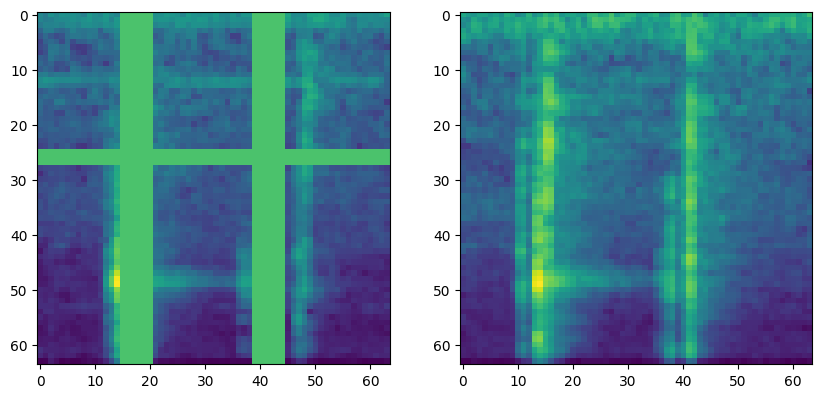

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(train_set[0][0][0], cmap='viridis')
ax2.imshow(val_set[0][0][0], cmap='viridis')
print(train_set[0][0][0].shape)
ax1.grid(False)
ax2.grid(False)
plt.show()

### CNN Model

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, stride=1, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes=26):
        super().__init__()
        
        # Block 1: Conv2D 1->64
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout2d(0.25)
        
        # Block 2: Conv2D 64->128
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout2 = nn.Dropout2d(0.25)
        
        # Block 3: Conv2D 128->256
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout3 = nn.Dropout2d(0.25)
        
        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        # Dense layers
        self.fc1 = nn.Linear(256, 128)
        self.bn4 = nn.BatchNorm1d(128)
        self.dropout4 = nn.Dropout(0.5)
        
        self.fc2 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)
        x = self.dropout1(x)
        
        # Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool3(x)
        x = self.dropout3(x)
        
        # Global pooling and flatten
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        
        # Dense layers
        x = self.fc1(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.dropout4(x)
        
        x = self.fc2(x)
        
        return x

In [ ]:
model = CNN(num_classes=dataset.num_classes())

In [ ]:
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model.apply(init_weights)
model.to(device)

print("Number of parameters: {:,}".format(sum(p.numel() for p in model.parameters())))
print(f"Device: {device}")

summary(model, input_size=(1, 1, 64, 64))

Number of parameters: 407,066
Device: cuda


Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 26]                   --
├─Conv2d: 1-1                            [1, 64, 64, 64]           640
├─BatchNorm2d: 1-2                       [1, 64, 64, 64]           128
├─MaxPool2d: 1-3                         [1, 64, 32, 32]           --
├─Dropout2d: 1-4                         [1, 64, 32, 32]           --
├─Conv2d: 1-5                            [1, 128, 32, 32]          73,856
├─BatchNorm2d: 1-6                       [1, 128, 32, 32]          256
├─MaxPool2d: 1-7                         [1, 128, 16, 16]          --
├─Dropout2d: 1-8                         [1, 128, 16, 16]          --
├─Conv2d: 1-9                            [1, 256, 16, 16]          295,168
├─BatchNorm2d: 1-10                      [1, 256, 16, 16]          512
├─MaxPool2d: 1-11                        [1, 256, 8, 8]            --
├─Dropout2d: 1-12                        [1, 256, 8, 8]            --
├─

### Training setup

In [ ]:
train_dataloader = torch.utils.data.DataLoader(
    train_set,
    batch_size=32,
    shuffle=True
)

val_dataloader = torch.utils.data.DataLoader(
    val_set,
    batch_size=32,
    shuffle=False
)

test_dataloader = torch.utils.data.DataLoader(
    test_set,
    batch_size=32,
    shuffle=False
)

In [ ]:
cost = nn.CrossEntropyLoss()

learning_rate = 1e-3
weight_decay = 1e-4
num_epochs = 200

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

### Training

In [ ]:
def plot_results(train_losses, train_accuracies, val_losses, val_accuracies):
    plt.figure(figsize=(12, 4))
    plt.subplot(1,2,1)
    plt.title("Loss")
    plt.plot(train_losses)
    plt.plot(val_losses)
    plt.legend(["Training loss", "Validation loss"], loc="best")
    plt.subplot(1,2,2)
    plt.title("Accuracy")
    plt.plot(train_accuracies)
    plt.plot(val_accuracies)
    plt.legend(["Training accuracy", "Validation accuracy"], loc="best")
    plt.show()

In [ ]:
def save_model(model, path):
    torch.save(model.state_dict(), path)

Epoch [1/200], Train Loss: 3.8700, Train Acc: 0.0358, Val Loss: 3.3366, Val Acc: 0.0455
  ✓ Best model saved with validation accuracy: 0.0455
Epoch [2/200], Train Loss: 3.5769, Train Acc: 0.0497, Val Loss: 3.2552, Val Acc: 0.0713
  ✓ Best model saved with validation accuracy: 0.0713
Epoch [3/200], Train Loss: 3.4582, Train Acc: 0.0533, Val Loss: 3.2342, Val Acc: 0.0556
Epoch [4/200], Train Loss: 3.3752, Train Acc: 0.0601, Val Loss: 3.2012, Val Acc: 0.0525
Epoch [5/200], Train Loss: 3.3264, Train Acc: 0.0580, Val Loss: 3.1189, Val Acc: 0.1129
  ✓ Best model saved with validation accuracy: 0.1129
Epoch [6/200], Train Loss: 3.2821, Train Acc: 0.0679, Val Loss: 3.1196, Val Acc: 0.0917
Epoch [7/200], Train Loss: 3.2501, Train Acc: 0.0684, Val Loss: 3.1233, Val Acc: 0.0940
Epoch [8/200], Train Loss: 3.2166, Train Acc: 0.0742, Val Loss: 3.1020, Val Acc: 0.1058
Epoch [9/200], Train Loss: 3.1998, Train Acc: 0.0765, Val Loss: 3.0626, Val Acc: 0.1074
Epoch [10/200], Train Loss: 3.1650, Train Acc:

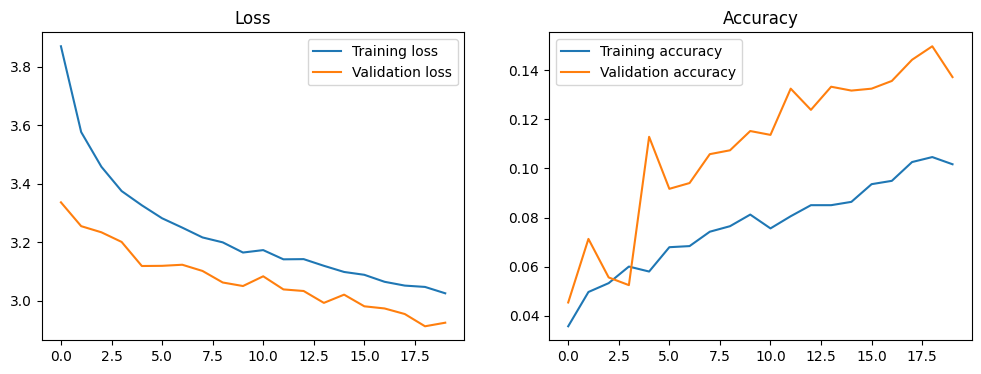

Epoch [21/200], Train Loss: 3.0263, Train Acc: 0.1055, Val Loss: 2.8976, Val Acc: 0.1395
Epoch [22/200], Train Loss: 3.0195, Train Acc: 0.1066, Val Loss: 2.8969, Val Acc: 0.1285
Epoch [23/200], Train Loss: 2.9896, Train Acc: 0.1190, Val Loss: 2.8487, Val Acc: 0.1646
  ✓ Best model saved with validation accuracy: 0.1646
Epoch [24/200], Train Loss: 2.9876, Train Acc: 0.1134, Val Loss: 2.8024, Val Acc: 0.1912
  ✓ Best model saved with validation accuracy: 0.1912
Epoch [25/200], Train Loss: 2.9527, Train Acc: 0.1253, Val Loss: 2.8129, Val Acc: 0.1646
Epoch [26/200], Train Loss: 2.9276, Train Acc: 0.1271, Val Loss: 2.7792, Val Acc: 0.1732
Epoch [27/200], Train Loss: 2.9029, Train Acc: 0.1361, Val Loss: 2.6980, Val Acc: 0.2139
  ✓ Best model saved with validation accuracy: 0.2139
Epoch [28/200], Train Loss: 2.9014, Train Acc: 0.1321, Val Loss: 2.6949, Val Acc: 0.2030
Epoch [29/200], Train Loss: 2.8660, Train Acc: 0.1357, Val Loss: 2.6407, Val Acc: 0.2155
  ✓ Best model saved with validation 

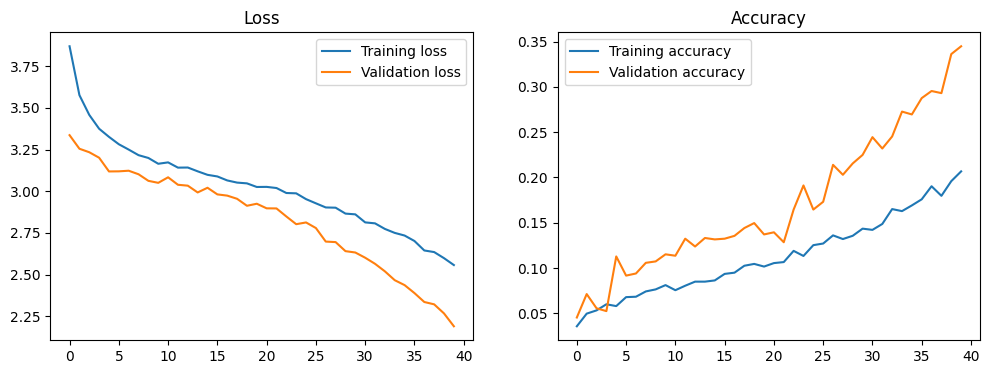

  ✓ Best model saved with validation accuracy: 0.3448
Epoch [41/200], Train Loss: 2.5291, Train Acc: 0.2085, Val Loss: 2.1288, Val Acc: 0.3456
  ✓ Best model saved with validation accuracy: 0.3456
Epoch [42/200], Train Loss: 2.4754, Train Acc: 0.2306, Val Loss: 2.0637, Val Acc: 0.4107
  ✓ Best model saved with validation accuracy: 0.4107
Epoch [43/200], Train Loss: 2.4502, Train Acc: 0.2394, Val Loss: 1.9870, Val Acc: 0.4193
  ✓ Best model saved with validation accuracy: 0.4193
Epoch [44/200], Train Loss: 2.4260, Train Acc: 0.2414, Val Loss: 1.9416, Val Acc: 0.4397
  ✓ Best model saved with validation accuracy: 0.4397
Epoch [45/200], Train Loss: 2.3503, Train Acc: 0.2702, Val Loss: 1.8369, Val Acc: 0.4632
  ✓ Best model saved with validation accuracy: 0.4632
Epoch [46/200], Train Loss: 2.2944, Train Acc: 0.2884, Val Loss: 1.7578, Val Acc: 0.5024
  ✓ Best model saved with validation accuracy: 0.5024
Epoch [47/200], Train Loss: 2.2443, Train Acc: 0.3021, Val Loss: 1.7170, Val Acc: 0.4663

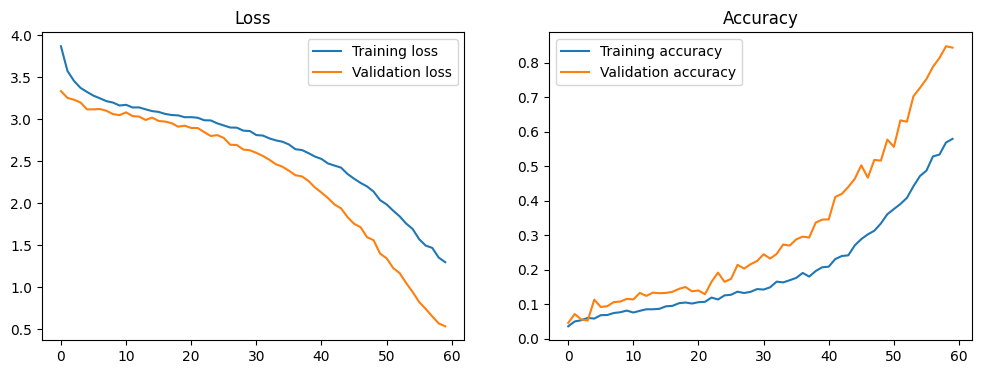

Epoch [61/200], Train Loss: 1.2236, Train Acc: 0.6083, Val Loss: 0.4441, Val Acc: 0.8824
  ✓ Best model saved with validation accuracy: 0.8824
Epoch [62/200], Train Loss: 1.1706, Train Acc: 0.6281, Val Loss: 0.4088, Val Acc: 0.8926
  ✓ Best model saved with validation accuracy: 0.8926
Epoch [63/200], Train Loss: 1.1349, Train Acc: 0.6414, Val Loss: 0.3185, Val Acc: 0.9169
  ✓ Best model saved with validation accuracy: 0.9169
Epoch [64/200], Train Loss: 1.0265, Train Acc: 0.6853, Val Loss: 0.2719, Val Acc: 0.9232
  ✓ Best model saved with validation accuracy: 0.9232
Epoch [65/200], Train Loss: 1.0104, Train Acc: 0.6823, Val Loss: 0.2825, Val Acc: 0.9161
Epoch [66/200], Train Loss: 0.9309, Train Acc: 0.6961, Val Loss: 0.2189, Val Acc: 0.9483
  ✓ Best model saved with validation accuracy: 0.9483
Epoch [67/200], Train Loss: 0.8732, Train Acc: 0.7215, Val Loss: 0.1876, Val Acc: 0.9600
  ✓ Best model saved with validation accuracy: 0.9600
Epoch [68/200], Train Loss: 0.8364, Train Acc: 0.7379

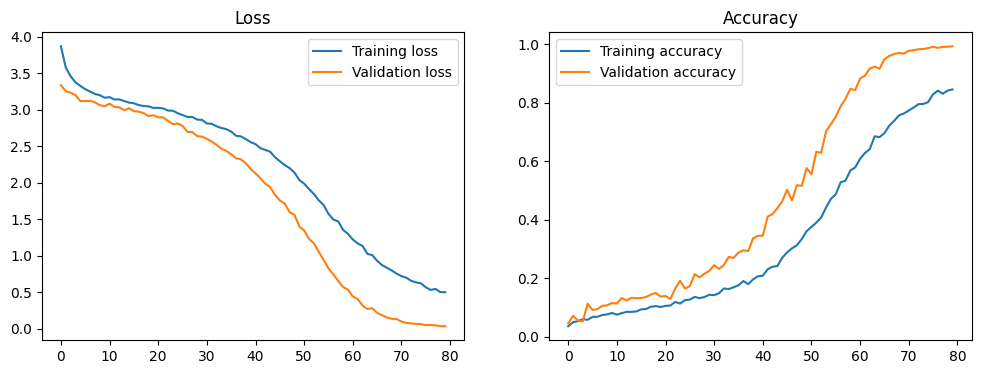

  ✓ Best model saved with validation accuracy: 0.9929
Epoch [81/200], Train Loss: 0.4660, Train Acc: 0.8562, Val Loss: 0.0282, Val Acc: 0.9945
  ✓ Best model saved with validation accuracy: 0.9945
Epoch [82/200], Train Loss: 0.4886, Train Acc: 0.8522, Val Loss: 0.0296, Val Acc: 0.9929
Epoch [83/200], Train Loss: 0.4727, Train Acc: 0.8513, Val Loss: 0.0255, Val Acc: 0.9937
Epoch [84/200], Train Loss: 0.4463, Train Acc: 0.8646, Val Loss: 0.0281, Val Acc: 0.9898
Epoch [85/200], Train Loss: 0.4372, Train Acc: 0.8589, Val Loss: 0.0230, Val Acc: 0.9937
Epoch [86/200], Train Loss: 0.4383, Train Acc: 0.8592, Val Loss: 0.0186, Val Acc: 0.9945
Epoch [87/200], Train Loss: 0.4117, Train Acc: 0.8709, Val Loss: 0.0207, Val Acc: 0.9929
Epoch [88/200], Train Loss: 0.3900, Train Acc: 0.8778, Val Loss: 0.0180, Val Acc: 0.9969
  ✓ Best model saved with validation accuracy: 0.9969
Epoch [89/200], Train Loss: 0.4019, Train Acc: 0.8740, Val Loss: 0.0200, Val Acc: 0.9929
Epoch [90/200], Train Loss: 0.3767, T

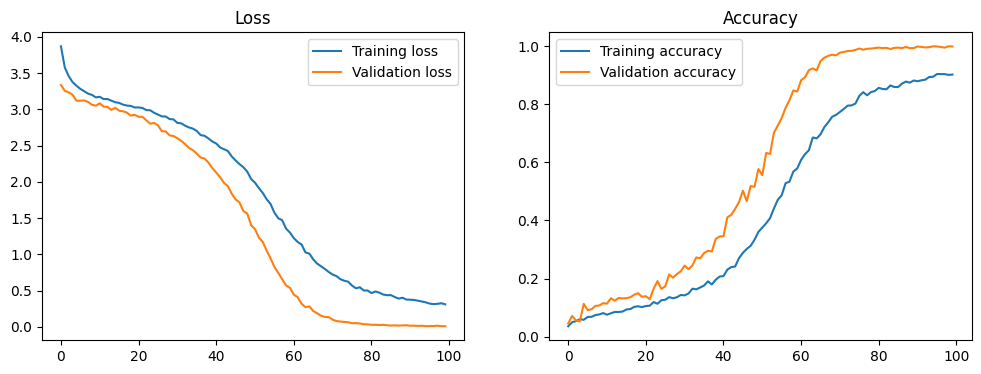

Epoch [101/200], Train Loss: 0.3146, Train Acc: 0.9071, Val Loss: 0.0077, Val Acc: 0.9992
Epoch [102/200], Train Loss: 0.3278, Train Acc: 0.8997, Val Loss: 0.0138, Val Acc: 0.9937
Epoch [103/200], Train Loss: 0.2824, Train Acc: 0.9082, Val Loss: 0.0072, Val Acc: 0.9992
Epoch [104/200], Train Loss: 0.2902, Train Acc: 0.9071, Val Loss: 0.0071, Val Acc: 0.9976
Epoch [105/200], Train Loss: 0.2849, Train Acc: 0.9132, Val Loss: 0.0085, Val Acc: 0.9976
Epoch [106/200], Train Loss: 0.2708, Train Acc: 0.9168, Val Loss: 0.0067, Val Acc: 0.9992
Epoch [107/200], Train Loss: 0.2965, Train Acc: 0.9107, Val Loss: 0.0061, Val Acc: 0.9992
Epoch [108/200], Train Loss: 0.2417, Train Acc: 0.9289, Val Loss: 0.0050, Val Acc: 0.9992
Epoch [109/200], Train Loss: 0.2781, Train Acc: 0.9161, Val Loss: 0.0072, Val Acc: 0.9976
Epoch [110/200], Train Loss: 0.2773, Train Acc: 0.9105, Val Loss: 0.0068, Val Acc: 0.9976
Epoch [111/200], Train Loss: 0.2596, Train Acc: 0.9224, Val Loss: 0.0078, Val Acc: 0.9976
Epoch [112

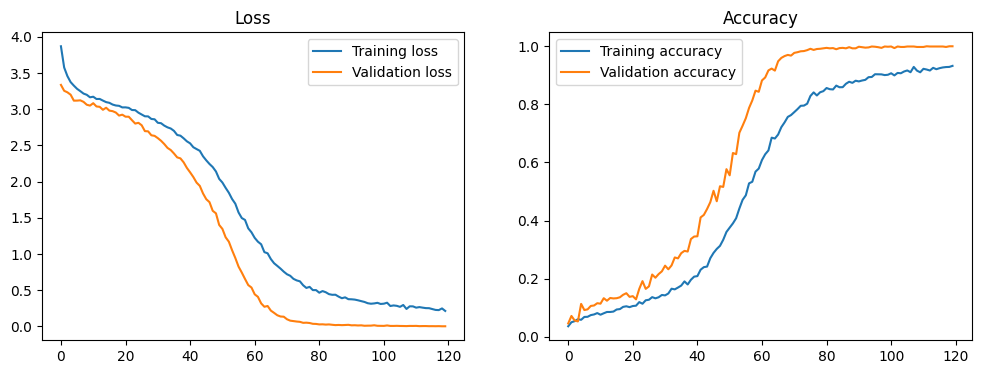

Epoch [121/200], Train Loss: 0.2258, Train Acc: 0.9305, Val Loss: 0.0026, Val Acc: 1.0000
Epoch [122/200], Train Loss: 0.2087, Train Acc: 0.9377, Val Loss: 0.0028, Val Acc: 1.0000
Epoch [123/200], Train Loss: 0.2390, Train Acc: 0.9253, Val Loss: 0.0031, Val Acc: 1.0000
Epoch [124/200], Train Loss: 0.2245, Train Acc: 0.9343, Val Loss: 0.0042, Val Acc: 1.0000
Epoch [125/200], Train Loss: 0.2091, Train Acc: 0.9336, Val Loss: 0.0036, Val Acc: 1.0000
Epoch [126/200], Train Loss: 0.2097, Train Acc: 0.9332, Val Loss: 0.0040, Val Acc: 0.9984
Epoch [127/200], Train Loss: 0.2101, Train Acc: 0.9375, Val Loss: 0.0023, Val Acc: 1.0000
Epoch [128/200], Train Loss: 0.2248, Train Acc: 0.9303, Val Loss: 0.0027, Val Acc: 1.0000
Epoch [129/200], Train Loss: 0.2080, Train Acc: 0.9395, Val Loss: 0.0023, Val Acc: 0.9992
Epoch [130/200], Train Loss: 0.2116, Train Acc: 0.9350, Val Loss: 0.0028, Val Acc: 1.0000
Epoch [131/200], Train Loss: 0.2011, Train Acc: 0.9370, Val Loss: 0.0009, Val Acc: 1.0000
Epoch [132

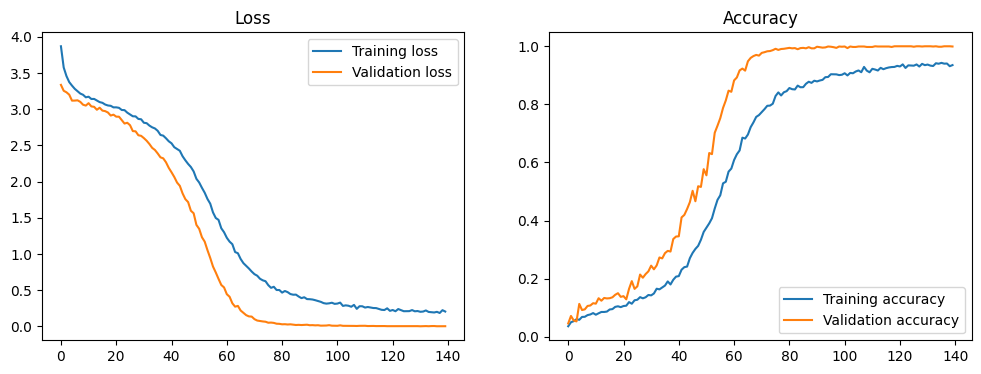

Epoch [141/200], Train Loss: 0.1988, Train Acc: 0.9395, Val Loss: 0.0024, Val Acc: 0.9992
Epoch [142/200], Train Loss: 0.1846, Train Acc: 0.9415, Val Loss: 0.0026, Val Acc: 0.9992
Epoch [143/200], Train Loss: 0.1500, Train Acc: 0.9564, Val Loss: 0.0017, Val Acc: 1.0000
Epoch [144/200], Train Loss: 0.1581, Train Acc: 0.9512, Val Loss: 0.0011, Val Acc: 1.0000
Epoch [145/200], Train Loss: 0.1503, Train Acc: 0.9534, Val Loss: 0.0015, Val Acc: 1.0000
Epoch [146/200], Train Loss: 0.1389, Train Acc: 0.9591, Val Loss: 0.0018, Val Acc: 1.0000
Epoch [147/200], Train Loss: 0.1637, Train Acc: 0.9505, Val Loss: 0.0012, Val Acc: 1.0000
Epoch [148/200], Train Loss: 0.1437, Train Acc: 0.9561, Val Loss: 0.0009, Val Acc: 1.0000
Epoch [149/200], Train Loss: 0.1442, Train Acc: 0.9566, Val Loss: 0.0005, Val Acc: 1.0000
Epoch [150/200], Train Loss: 0.1408, Train Acc: 0.9584, Val Loss: 0.0006, Val Acc: 1.0000
Epoch [151/200], Train Loss: 0.1345, Train Acc: 0.9568, Val Loss: 0.0006, Val Acc: 1.0000
Epoch [152

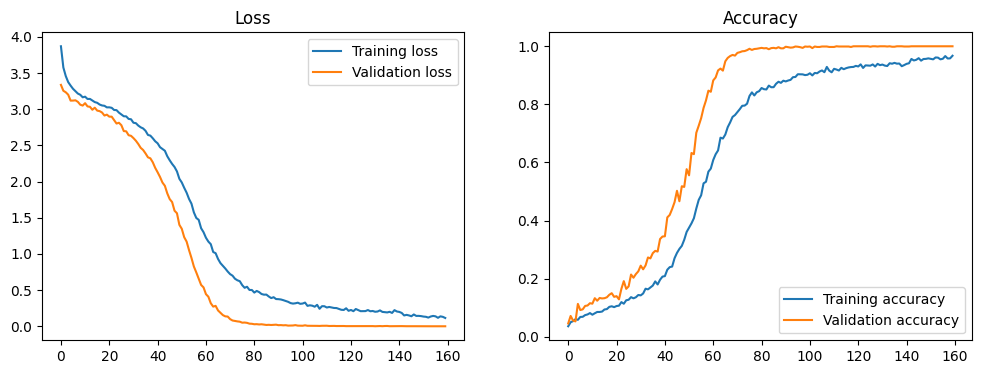

Epoch [161/200], Train Loss: 0.1340, Train Acc: 0.9588, Val Loss: 0.0004, Val Acc: 1.0000
Epoch [162/200], Train Loss: 0.1241, Train Acc: 0.9631, Val Loss: 0.0004, Val Acc: 1.0000
Epoch [163/200], Train Loss: 0.1443, Train Acc: 0.9534, Val Loss: 0.0004, Val Acc: 1.0000
Epoch [164/200], Train Loss: 0.1229, Train Acc: 0.9647, Val Loss: 0.0004, Val Acc: 1.0000
Epoch [165/200], Train Loss: 0.1131, Train Acc: 0.9636, Val Loss: 0.0004, Val Acc: 1.0000
Epoch [166/200], Train Loss: 0.1272, Train Acc: 0.9602, Val Loss: 0.0006, Val Acc: 1.0000
Epoch [167/200], Train Loss: 0.1335, Train Acc: 0.9595, Val Loss: 0.0002, Val Acc: 1.0000
Epoch [168/200], Train Loss: 0.1374, Train Acc: 0.9595, Val Loss: 0.0004, Val Acc: 1.0000
Epoch [169/200], Train Loss: 0.1363, Train Acc: 0.9600, Val Loss: 0.0004, Val Acc: 1.0000
Epoch [170/200], Train Loss: 0.1321, Train Acc: 0.9606, Val Loss: 0.0003, Val Acc: 1.0000
Epoch [171/200], Train Loss: 0.1329, Train Acc: 0.9575, Val Loss: 0.0005, Val Acc: 1.0000
Epoch [172

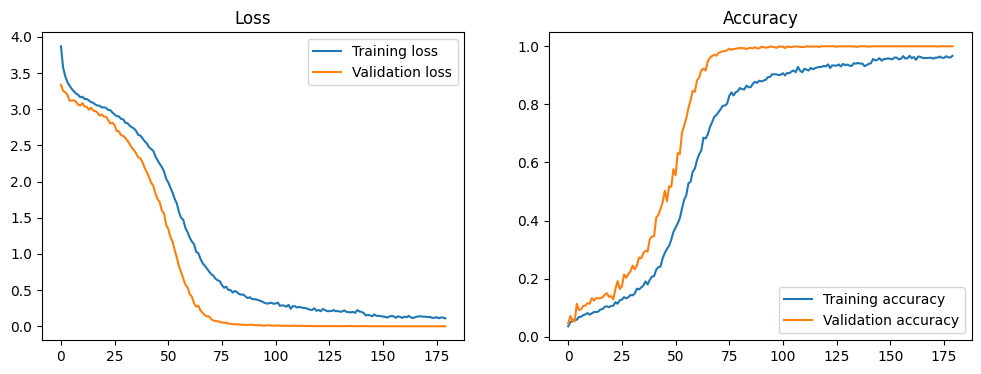

Epoch [181/200], Train Loss: 0.0951, Train Acc: 0.9728, Val Loss: 0.0003, Val Acc: 1.0000
Epoch [182/200], Train Loss: 0.0984, Train Acc: 0.9732, Val Loss: 0.0003, Val Acc: 1.0000
Epoch [183/200], Train Loss: 0.0932, Train Acc: 0.9723, Val Loss: 0.0004, Val Acc: 1.0000
Epoch [184/200], Train Loss: 0.0991, Train Acc: 0.9721, Val Loss: 0.0004, Val Acc: 1.0000
Epoch [185/200], Train Loss: 0.1050, Train Acc: 0.9672, Val Loss: 0.0003, Val Acc: 1.0000
Epoch [186/200], Train Loss: 0.1036, Train Acc: 0.9705, Val Loss: 0.0003, Val Acc: 1.0000
Epoch [187/200], Train Loss: 0.0911, Train Acc: 0.9728, Val Loss: 0.0003, Val Acc: 1.0000
Epoch [188/200], Train Loss: 0.1140, Train Acc: 0.9665, Val Loss: 0.0003, Val Acc: 1.0000
Epoch [189/200], Train Loss: 0.0995, Train Acc: 0.9699, Val Loss: 0.0003, Val Acc: 1.0000
Epoch [190/200], Train Loss: 0.0894, Train Acc: 0.9719, Val Loss: 0.0003, Val Acc: 1.0000
Epoch [191/200], Train Loss: 0.0913, Train Acc: 0.9721, Val Loss: 0.0003, Val Acc: 1.0000
Epoch [192

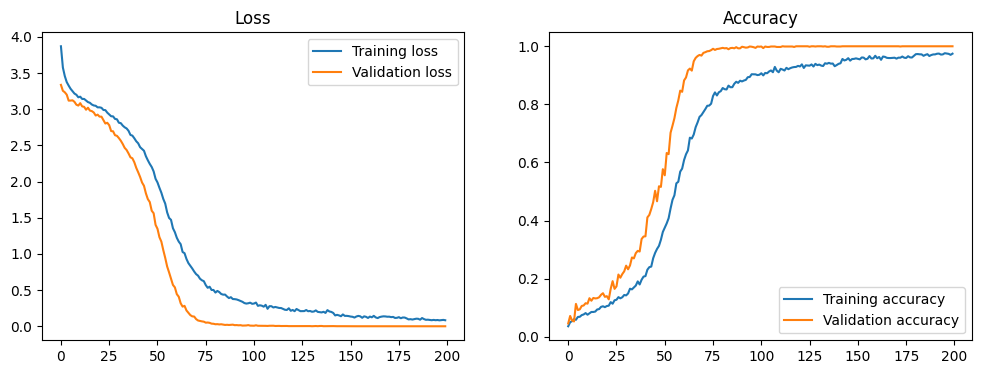

In [ ]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0
    epoch_loss = 0
    
    for inputs, labels in train_dataloader:
        inputs = inputs.to(device)
        labels = torch.squeeze(labels).to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = cost(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        epoch_loss += loss.item()
    
    train_acc = correct / total
    avg_train_loss = epoch_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)
    
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        val_loss = 0
        
        for inputs, labels in val_dataloader:
            inputs = inputs.to(device)
            labels = torch.squeeze(labels).to(device)
            outputs = model(inputs)
            
            loss = cost(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        val_acc = correct / total
        avg_val_loss = val_loss / len(val_dataloader)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)
    
    scheduler.step(avg_val_loss)
    
    print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    if epoch != 0 and (epoch % 20 == 19):
        plot_results(train_losses, train_accuracies, val_losses, val_accuracies)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_model(model, best_model_path)
        print(f"  ✓ Best model saved with validation accuracy: {val_acc:.4f}")

In [ ]:
save_model(model, model_path)

In [ ]:
print("Best validation acc:", max(val_accuracies))
print("Last validation acc:", val_accuracies[-1])

Best validation acc: 1.0
Last validation acc: 1.0


## 🚨 DATA LEAKAGE DIAGNOSTICS 🚨

### 1. Check for duplicate/similar audio files

In [ ]:
# Check for duplicate samples across splits
import hashlib

def get_audio_hash(waveform):
    """Get hash of audio data to detect duplicates"""
    return hashlib.md5(waveform.numpy().tobytes()).hexdigest()

# Get hashes from each split
train_hashes = set()
val_hashes = set()
test_hashes = set()

print("Computing hashes for train set...")
for waveform, _ in tqdm(init_train_set):
    train_hashes.add(get_audio_hash(waveform))

print("Computing hashes for validation set...")
for waveform, _ in tqdm(init_val_set):
    val_hashes.add(get_audio_hash(waveform))

print("Computing hashes for test set...")
for waveform, _ in tqdm(init_test_set):
    test_hashes.add(get_audio_hash(waveform))

# Check for overlaps
train_val_overlap = train_hashes & val_hashes
train_test_overlap = train_hashes & test_hashes
val_test_overlap = val_hashes & test_hashes

print(f"\n🔍 DUPLICATE CHECK RESULTS:")
print(f"Train samples: {len(train_hashes)}")
print(f"Val samples: {len(val_hashes)}")
print(f"Test samples: {len(test_hashes)}")
print(f"\n⚠️ Train-Val overlap: {len(train_val_overlap)} samples")
print(f"⚠️ Train-Test overlap: {len(train_test_overlap)} samples")
print(f"⚠️ Val-Test overlap: {len(val_test_overlap)} samples")

if len(train_val_overlap) > 0 or len(train_test_overlap) > 0:
    print("\n🚨 DATA LEAKAGE DETECTED: Duplicate samples found across splits!")
else:
    print("\n✅ No exact duplicates found")

Computing hashes for train set...


NameError: name 'tqdm' is not defined

### 2. SHUFFLE LABELS TEST (Most Critical)

In [ ]:
# If validation accuracy is high with RANDOM labels, you have data leakage!

class ShuffledDataset(Dataset):
    """Dataset with randomly shuffled labels - should give ~random accuracy"""
    def __init__(self, base_dataset):
        super().__init__()
        self.base = base_dataset
        # Collect all labels and shuffle them
        all_labels = [base_dataset[i][1] for i in range(len(base_dataset))]
        self.shuffled_labels = all_labels.copy()
        random.shuffle(self.shuffled_labels)
    
    def __len__(self):
        return len(self.base)
    
    def __getitem__(self, idx):
        waveform, _ = self.base[idx]
        return waveform, self.shuffled_labels[idx]

# Create datasets with shuffled labels
shuffled_train = ShuffledDataset(train_set_no_aug)
shuffled_val = ShuffledDataset(val_set)

shuffled_train_loader = DataLoader(shuffled_train, batch_size=32, shuffle=True)
shuffled_val_loader = DataLoader(shuffled_val, batch_size=32, shuffle=False)

# Train a model on random labels
print("🧪 SHUFFLE TEST: Training model with RANDOM labels...")
print("Expected val accuracy if no leakage: ~3.85% (1/26 classes)")
print("If accuracy is high (>10%), DATA LEAKAGE CONFIRMED!\n")

test_model = CNN(num_classes=dataset.num_classes())
test_model.apply(init_weights)
test_model.to(device)

test_optimizer = optim.Adam(test_model.parameters(), lr=1e-3, weight_decay=1e-4)
test_cost = nn.CrossEntropyLoss()

num_test_epochs = 20

for epoch in range(num_test_epochs):
    test_model.train()
    for inputs, labels in shuffled_train_loader:
        inputs = inputs.to(device)
        labels = torch.squeeze(labels).to(device)
        test_optimizer.zero_grad()
        outputs = test_model(inputs)
        loss = test_cost(outputs, labels)
        loss.backward()
        test_optimizer.step()
    
    # Evaluate on validation
    test_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in shuffled_val_loader:
            inputs = inputs.to(device)
            labels = torch.squeeze(labels).to(device)
            outputs = test_model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_acc = correct / total
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1}/{num_test_epochs}, Shuffled Val Acc: {val_acc:.4f}")

print(f"\n🔍 FINAL SHUFFLED VALIDATION ACCURACY: {val_acc:.4f}")
print(f"Random baseline: {1/26:.4f} (3.85%)")

if val_acc > 0.10:
    print("🚨 CRITICAL: Data leakage detected! Model performs better than random on shuffled labels!")
elif val_acc > 0.06:
    print("⚠️ WARNING: Slightly elevated accuracy - possible minor leakage")
else:
    print("✅ PASS: Accuracy near random baseline - no obvious label leakage")

### 3. Check file naming patterns for temporal correlation

In [ ]:
# Check if consecutive files are being split across train/val/test
# This would cause leakage if files from same recording session are similar

data_dir = 'Data/segmented/alpha-large'
file_info = []

for dirname, _, filenames in os.walk(data_dir):
    label = os.path.basename(dirname)
    if label and (label.isdigit() or label.isalpha()):
        for filename in sorted(filenames):
            file_path = os.path.join(dirname, filename)
            file_info.append({
                'path': file_path,
                'label': label,
                'filename': filename
            })

print(f"Total files loaded: {len(file_info)}")
print(f"\nSample filenames from first label:")
first_label_files = [f['filename'] for f in file_info if f['label'] == file_info[0]['label']][:10]
for fname in first_label_files:
    print(f"  {fname}")

# Check if filenames contain session/recording identifiers
print("\n🔍 Checking for potential session identifiers in filenames...")
sample_names = [f['filename'] for f in file_info[:20]]
print("Sample filenames:")
for name in sample_names:
    print(f"  {name}")

print("\n⚠️ CONCERN: If these filenames contain:")
print("  - Recording session IDs")
print("  - Timestamps from same recording")
print("  - Sequential numbers from continuous recording")
print("Then consecutive files are CORRELATED and random split causes leakage!")
print("\nExample: file_001.wav and file_002.wav might be 100ms apart from same recording")

### 4. Check validation set size and distribution

In [ ]:
# Check if validation set is too small or imbalanced

from collections import Counter

train_labels = [init_train_set[i][1].item() for i in range(len(init_train_set))]
val_labels = [init_val_set[i][1].item() for i in range(len(init_val_set))]
test_labels = [init_test_set[i][1].item() for i in range(len(init_test_set))]

train_dist = Counter(train_labels)
val_dist = Counter(val_labels)
test_dist = Counter(test_labels)

print(f"📊 DATASET SIZE ANALYSIS:")
print(f"Train: {len(train_labels)} samples")
print(f"Val: {len(val_labels)} samples")
print(f"Test: {len(test_labels)} samples")

print(f"\n📊 SAMPLES PER CLASS:")
print(f"Train - min: {min(train_dist.values())}, max: {max(train_dist.values())}, avg: {np.mean(list(train_dist.values())):.1f}")
print(f"Val - min: {min(val_dist.values())}, max: {max(val_dist.values())}, avg: {np.mean(list(val_dist.values())):.1f}")
print(f"Test - min: {min(test_dist.values())}, max: {max(test_dist.values())}, avg: {np.mean(list(test_dist.values())):.1f}")

avg_val_per_class = len(val_labels) / len(val_dist)
if avg_val_per_class < 10:
    print(f"\n⚠️ WARNING: Validation set very small ({avg_val_per_class:.1f} samples/class)")
    print("Small validation sets can be memorized and give inflated accuracy!")
elif avg_val_per_class < 30:
    print(f"\n⚠️ CAUTION: Validation set relatively small ({avg_val_per_class:.1f} samples/class)")
else:
    print(f"\n✅ Validation set size adequate ({avg_val_per_class:.1f} samples/class)")

### 5. Verify transforms are not leaking information

In [ ]:
# Check that transforms are deterministic and don't use dataset statistics

print("🔍 TRANSFORM PIPELINE CHECK:")
print("\nTransforms used:")
print("1. MelSpectrogram - ✅ Deterministic, no dataset stats needed")
print("2. Log scaling - ✅ Deterministic")
print("3. ToTensor - ✅ Deterministic")
print("\nAugmentations (train only):")
print("1. TimeShifting - ✅ Random but independent")
print("2. FrequencyMasking - ✅ Random but independent")
print("3. TimeMasking - ✅ Random but independent")

print("\n✅ PASS: Transforms don't require dataset-wide statistics")
print("✅ PASS: Augmentation only applied to training set")
print("\n⚠️ NOTE: This doesn't rule out OTHER forms of leakage!")

### 6. Audio similarity analysis (temporal correlation)

In [ ]:
# Check if samples from train and val are suspiciously similar
# Sample a few from each and compute cosine similarity

from sklearn.metrics.pairwise import cosine_similarity

n_samples = 50
train_samples = [transforms(init_train_set[i][0]).flatten().numpy() for i in range(min(n_samples, len(init_train_set)))]
val_samples = [transforms(init_val_set[i][0]).flatten().numpy() for i in range(min(n_samples, len(init_val_set)))]

train_matrix = np.array(train_samples)
val_matrix = np.array(val_samples)

# Compute cross-similarity between train and val
cross_sim = cosine_similarity(train_matrix, val_matrix)

# Get max similarity for each validation sample with ANY train sample
max_similarities = cross_sim.max(axis=0)
avg_max_sim = max_similarities.mean()
high_sim_count = (max_similarities > 0.95).sum()

print(f"🔍 AUDIO SIMILARITY ANALYSIS (train vs val):")
print(f"Average max similarity: {avg_max_sim:.4f}")
print(f"Samples with >0.95 similarity: {high_sim_count}/{len(max_similarities)}")
print(f"Max similarity found: {max_similarities.max():.4f}")

if high_sim_count > len(max_similarities) * 0.1:
    print(f"\n🚨 CRITICAL: {high_sim_count} validation samples are VERY similar to training samples!")
    print("This suggests audio files from same recording session are split across train/val!")
elif avg_max_sim > 0.85:
    print(f"\n⚠️ WARNING: High average similarity suggests correlated samples")
else:
    print(f"\n✅ Similarity levels reasonable")

print("\n💡 If high similarity found, this is likely because:")
print("  - Files from same recording session split randomly")
print("  - Consecutive keystrokes from same person/keyboard/mic")
print("  - Need SESSION-BASED split, not RANDOM split!")

### 7. Summary and Recommendations

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║                     DIAGNOSIS COMPLETE                           ║
╚══════════════════════════════════════════════════════════════════╝

Run the cells above to check for:
✓ 1. Duplicate samples across splits (exact hash matches)
✓ 2. Label leakage (shuffle test - MOST IMPORTANT)
✓ 3. Temporal correlation in filenames
✓ 4. Validation set size issues
✓ 5. Transform pipeline correctness
✓ 6. Audio similarity between splits

🚨 KEY ISSUES TO LOOK FOR:

1. SHUFFLE TEST accuracy > 10% 
   → Label leakage confirmed

2. High similarity scores (>0.95) between train and val
   → Same recording session split across sets

3. Sequential filenames (file_001, file_002, etc.)
   → Consecutive keystrokes from same recording

4. Val set < 30 samples per class
   → Model might memorize validation set

═══════════════════════════════════════════════════════════════════

📋 HOW TO FIX (if leakage found):

1. SESSION-BASED SPLITTING:
   - Group files by recording session
   - Split SESSIONS, not individual files
   - All files from Session A go to train
   - All files from Session B go to val

2. RE-COLLECT DATA:
   - Record train/val/test on DIFFERENT days
   - Different keyboard positions
   - Different background noise
   - Different recording gain

3. CROSS-VALIDATION:
   - Use 5-fold CV with session-aware splitting
   - Each fold uses different recording sessions

4. CONSERVATIVE EVALUATION:
   - Never trust validation accuracy alone
   - Always test on completely new recordings
   - Test on different hardware/environment

═══════════════════════════════════════════════════════════════════
""")

### Results

In [ ]:
model.load_state_dict(torch.load(best_model_path))
model.to(device)
model.eval()

CNN(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout2d(p=0.25, inplace=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout2d(p=0.25, inplace=False)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout3): Dropout2d(p=0.25, inplace=False)
  (global_pool): AdaptiveAvgPool2d(output_size=1)
  (fc1): Linear(in_features=256, out_feature

In [ ]:
digits = [str(digit) for digit in range(10)]
alphabet = [chr(ascii_code) for ascii_code in range(ord('A'), ord('Z') + 1)]
all_characters = digits + alphabet
label_dict = {i: all_characters[i] for i in range(len(all_characters))}
print(label_dict)

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E', 15: 'F', 16: 'G', 17: 'H', 18: 'I', 19: 'J', 20: 'K', 21: 'L', 22: 'M', 23: 'N', 24: 'O', 25: 'P', 26: 'Q', 27: 'R', 28: 'S', 29: 'T', 30: 'U', 31: 'V', 32: 'W', 33: 'X', 34: 'Y', 35: 'Z'}


In [ ]:
predictions_path = 'predictions-cnn.csv'

def predict(data_loader):
    original_labels = []
    predicted_labels = []
    correct = 0
    total = 0
    
    model.eval()
    
    for inputs, labels in data_loader:
        inputs = inputs.to(device)
        labels = torch.squeeze(labels).to(device)
        outputs = model(inputs)
        
        _, predicted = torch.max(outputs.data, 1)
      
        original_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predicted.cpu().numpy())
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    prediction_df = pd.DataFrame({
        "predicted_labels": [label_dict[pred] for pred in predicted_labels], 
        "true_labels": [label_dict[label] for label in original_labels]
    })
    prediction_df.to_csv(predictions_path)

    print(f"Test Accuracy: {correct/total}")
    pd.set_option('display.max_rows', None)
    pd.set_option("display.max_columns", None)
    display(prediction_df.T)
    
    print(metrics.accuracy_score(original_labels, predicted_labels))
    print(metrics.classification_report(original_labels, predicted_labels))
    
    return confusion_matrix(original_labels, predicted_labels)

### Test accuracy

In [ ]:
cm = predict(test_dataloader)

Test Accuracy: 1.0


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628
predicted_labels,B,E,A,O,P,N,9,1,6,O,9,1,I,C,E,K,4,4,O,C,H,G,4,C,H,I,E,F,H,B,P,N,J,E,O,9,6,5,O,G,G,J,8,3,6,L,B,B,1,N,2,J,I,C,H,7,5,H,M,0,7,I,L,D,7,K,C,F,3,J,N,L,H,F,G,P,D,8,6,F,4,4,7,K,2,E,4,6,O,H,4,4,G,N,J,6,L,D,K,6,A,H,9,2,3,A,J,8,E,F,3,K,D,P,I,C,L,K,3,L,A,7,A,O,J,7,8,M,B,C,H,J,B,4,L,8,A,H,3,L,A,9,F,1,0,1,K,H,N,8,O,I,N,7,I,5,1,9,8,J,B,7,1,6,C,6,F,9,E,M,B,8,6,6,K,B,H,D,1,9,F,L,6,7,8,8,A,G,K,4,B,5,N,O,M,J,O,E,F,O,I,O,K,9,J,K,J,G,9,E,D,A,O,P,4,N,M,L,3,H,F,I,K,M,B,6,9,I,M,L,E,D,J,2,0,A,5,O,L,M,E,P,N,C,5,2,O,M,4,1,4,8,P,J,F,M,E,F,J,B,6,4,N,H,P,I,8,J,C,H,8,7,G,5,M,0,J,6,6,E,P,F,J,L,F,C,K,N,I,N,0,4,4,1,D,M,N,D,1,O,A,9,A,K,L,D,8,C,F,E,D,G,D,D,C,C,6,8,L,A,5,F,P,3,C,P,1,G,I,E,D,P,O,J,0,E,A,G,K,G,2,K,P,6,O,K,8,E,M,9,F,O,2,3,L,I,C,0,H,N,M,O,8,8,G,4,9,L,M,N,N,G,M,F,M,5,B,8,C,6,H,D,2,O,9,4,7,G,M,H,G,H,O,G,O,P,F,K,3,H,D,N,2,A,M,1,O,E,P,M,N,5,I,B,0,L,5,0,M,G,J,7,D,J,G,6,9,4,A,E,B,H,5,F,J,5,P,C,O,J,9,O,0,P,M,B,A,9,K,D,M,3,6,B,2,N,C,0,L,O,D,7,D,A,8,9,2,2,9,P,7,7,L,9,F,K,C,2,A,P,B,M,F,3,K,I,A,H,C,7,K,6,G,6,I,A,L,4,E,N,G,L,C,D,5,9,I,7,4,F,7,F,E,5,N,G,9,B,B,L,P,P,O,I,A,I,H,0,N,9,N,E,K,J,1,K,3,H,7,0,K,M,P,A,D,A,I,G,5,L,C,A,M,G,P,G,3,E,3,3,C,C,1,I,G,M,M,P,A,P,L,E,E,5,N,N,8,L,B,4,9,B,K,5,B,I,K,M,P,C,D,N,J,K,H,7,D,8,F,3,P,2,0,H,5,H,4,J,N,8,J,G,L,0,A,J,M,B,1,H,6,9,I,I,4,G,H,K,5
true_labels,B,E,A,O,P,N,9,1,6,O,9,1,I,C,E,K,4,4,O,C,H,G,4,C,H,I,E,F,H,B,P,N,J,E,O,9,6,5,O,G,G,J,8,3,6,L,B,B,1,N,2,J,I,C,H,7,5,H,M,0,7,I,L,D,7,K,C,F,3,J,N,L,H,F,G,P,D,8,6,F,4,4,7,K,2,E,4,6,O,H,4,4,G,N,J,6,L,D,K,6,A,H,9,2,3,A,J,8,E,F,3,K,D,P,I,C,L,K,3,L,A,7,A,O,J,7,8,M,B,C,H,J,B,4,L,8,A,H,3,L,A,9,F,1,0,1,K,H,N,8,O,I,N,

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        24
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        24
           7       1.00      1.00      1.00        20
           8       1.00      1.00      1.00        23
           9       1.00      1.00      1.00        26
          10       1.00      1.00      1.00        27
          11       1.00      1.00      1.00        24
          12       1.00      1.00      1.00        26
          13       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        25
          15       1.00      1.00      1.00        25
          16       1.00      1.00      1.00        28
          17       1.00

### Confusion matrix

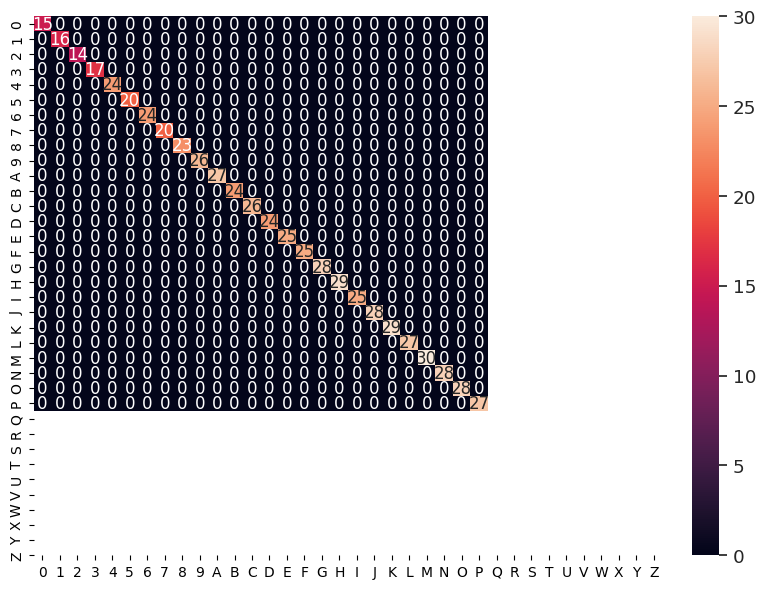

In [ ]:
fig, ax = plt.subplots(figsize=(10,7))
sns.set(font_scale=1.2)
ax = sns.heatmap(cm,
                annot=True,
                fmt='g',
                xticklabels=all_characters, 
                yticklabels=all_characters,
                annot_kws={"size": 12}
                )
fig.savefig("confusion_matrix_CNN.pdf", format='pdf', bbox_inches='tight')

### Single sample test

In [ ]:
test_root = '../../long'

label_folders = [f for f in os.listdir(test_root) if os.path.isdir(os.path.join(test_root, f))]
chosen_label = random.choice(label_folders)
label_path = os.path.join(test_root, chosen_label)

sample_files = [f for f in os.listdir(label_path) if os.path.isfile(os.path.join(label_path, f))]
chosen_file = random.choice(sample_files)
sample_path = os.path.join(label_path, chosen_file)

print(f"Testing with audio file: {sample_path}")
print(f"True label: {chosen_label.upper()}")

waveform, sr = torchaudio.load(sample_path)
input_tensor = transforms(waveform).unsqueeze(0).to(device)

print(f"Input tensor shape: {input_tensor.shape}")

model.eval()
with torch.no_grad():
    output = model(input_tensor)
    if output.dim() == 1:
        output = output.unsqueeze(0)
    probabilities = F.softmax(output, dim=1)
    predicted_idx = torch.argmax(output, dim=1).item()
    confidence = probabilities[0][predicted_idx].item()

predicted_label = label_dict[predicted_idx]

print(f"\nPredicted label: {predicted_label}")
print(f"Confidence: {confidence:.4f}")
print(f"\nTop 5 predictions:")
top5_probs, top5_indices = torch.topk(probabilities[0], 5)
for i, (prob, idx) in enumerate(zip(top5_probs, top5_indices)):
    print(f"  {i+1}. {label_dict[idx.item()]}: {prob.item():.4f}")

plt.figure(figsize=(10, 4))
plt.imshow(input_tensor.cpu().squeeze().numpy(), cmap='viridis', aspect='auto')
plt.colorbar(label='Log Magnitude')
plt.title(f'Mel Spectrogram - True: {chosen_label.upper()}, Predicted: {predicted_label}')
plt.xlabel('Time')
plt.ylabel('Mel Frequency')
plt.grid(False)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../../long'